# Week 7: Unsupervised Learning & Dimensionality Reduction
### AI/ML Fellowship — GDGOC ATK
##   Table of Contents
1. Imports & Setup
2. K-Means Clustering (From Scratch)
3. Hierarchical Clustering
4. PCA — Principal Component Analysis
5. t-SNE Visualization
6. Association Rule Mining (Apriori)
7. Market Basket Analysis Project
8. Conclusion

In [2]:
# Imports & Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


## 1. K-Means Clustering (From Scratch)
K-Means partitions data into K clusters by minimizing intra-cluster variance.
We implement it from scratch using only NumPy — no sklearn KMeans.

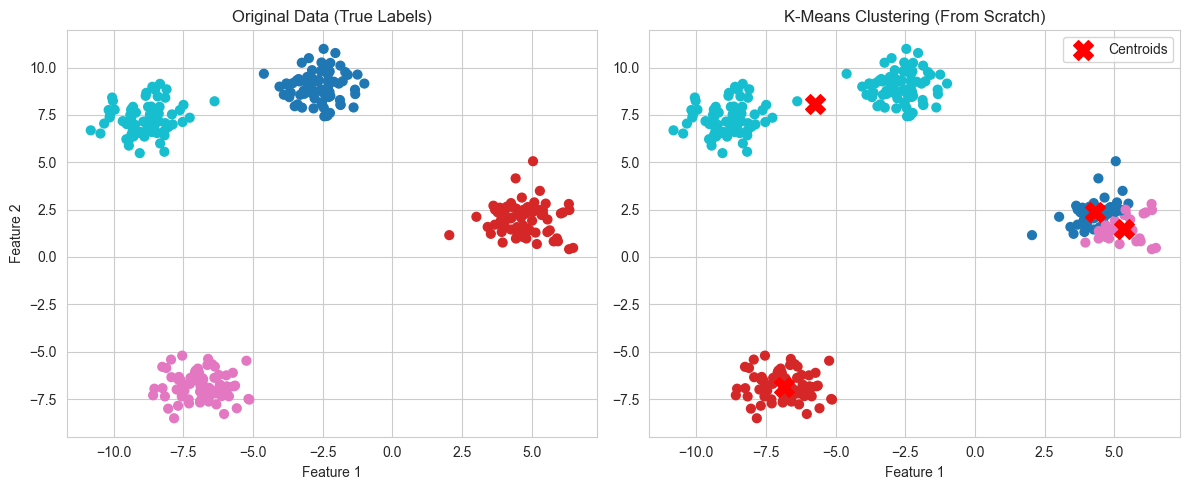

K-Means converged with 4 clusters


In [3]:
# K-MEANS CLUSTERING 

class KMeansScratch:
    def __init__(self, k=3, max_iters=100, random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        # Randomly initialize centroids
        indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[indices]

        for _ in range(self.max_iters):
            # Assign clusters
            self.labels = self._assign_clusters(X)
            # Update centroids
            new_centroids = np.array([X[self.labels == k].mean(axis=0) for k in range(self.k)])
            # Check convergence
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids
        return self

    def _assign_clusters(self, X):
        distances = np.array([[np.linalg.norm(x - c) for c in self.centroids] for x in X])
        return np.argmin(distances, axis=1)

    def predict(self, X):
        return self._assign_clusters(X)


# Generate sample data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Fit K-Means from scratch
kmeans = KMeansScratch(k=4)
kmeans.fit(X)
labels = kmeans.labels

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=40)
plt.title("Original Data (True Labels)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=40)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering (From Scratch)")
plt.xlabel("Feature 1")
plt.legend()
plt.tight_layout()
plt.show()

print(f"K-Means converged with {kmeans.k} clusters")

## 2. Hierarchical Clustering
Hierarchical clustering builds a tree of clusters (dendrogram).
We use **Agglomerative** (bottom-up) approach with Ward linkage.

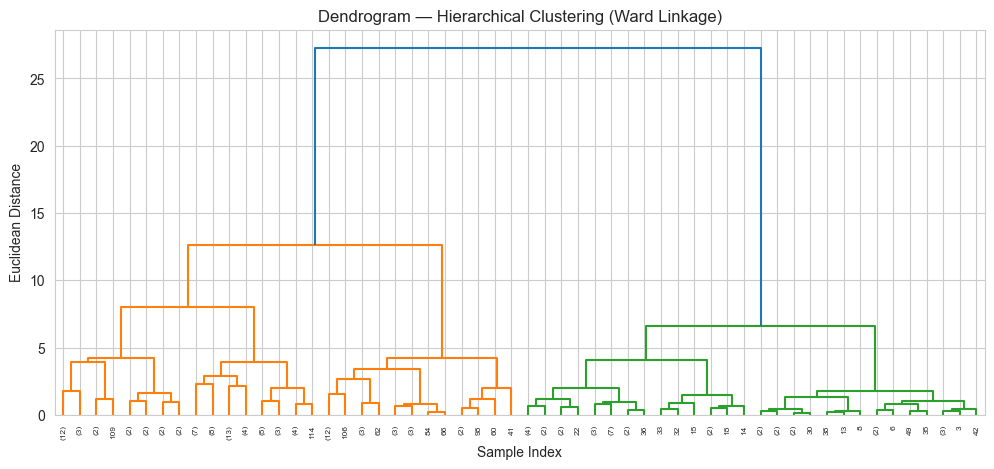

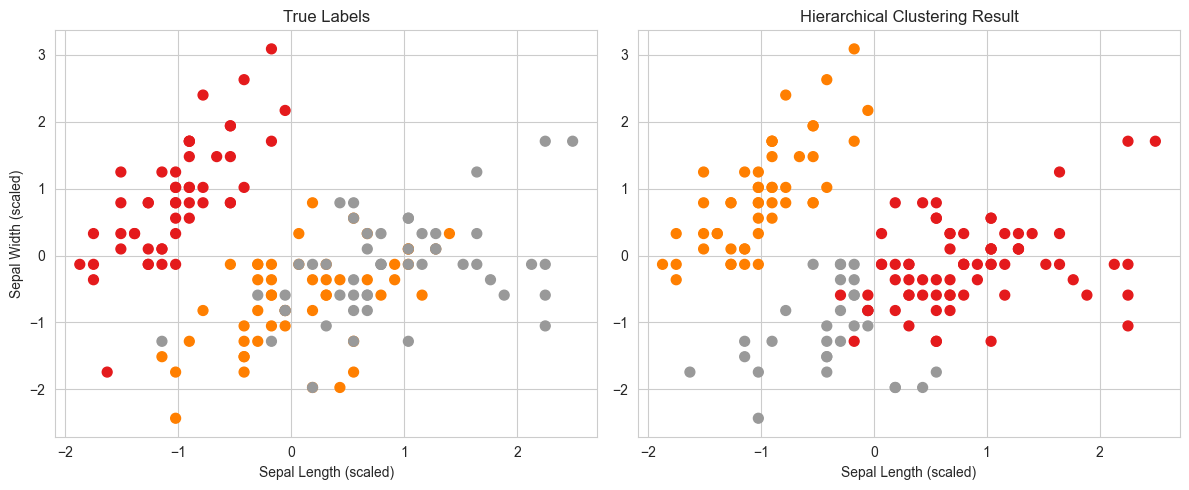

Hierarchical Clustering done!


In [4]:
# HIERARCHICAL CLUSTERING
# Use iris dataset for this section
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# Plot Dendrogram
plt.figure(figsize=(12, 5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='level',
           p=5)
plt.title("Dendrogram — Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")
plt.show()

# Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

# Visualize (using first 2 features)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_iris, cmap='Set1', s=50)
plt.title("True Labels")
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hc_labels, cmap='Set1', s=50)
plt.title("Hierarchical Clustering Result")
plt.xlabel("Sepal Length (scaled)")
plt.tight_layout()
plt.show()

print("Hierarchical Clustering done!")

## 3. PCA — Principal Component Analysis
PCA reduces dimensionality by projecting data onto directions of maximum variance.
We reduce the Iris dataset from 4D → 2D for visualization.

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 95.81%


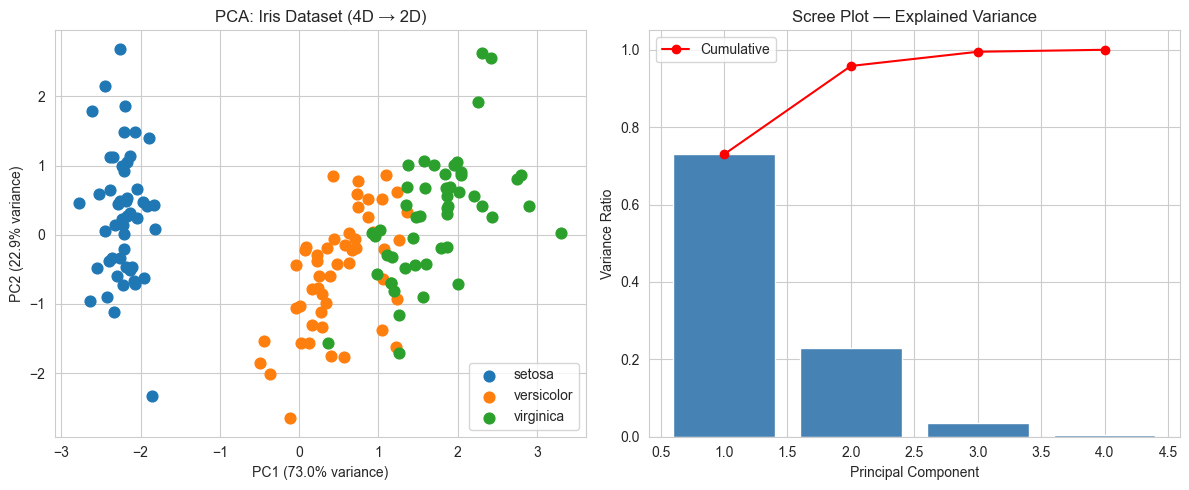

In [5]:
# PCA — PRINCIPAL COMPONENT ANALYSIS
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Plot PCA result
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, label in enumerate(iris.target_names):
    plt.scatter(X_pca[y_iris == i, 0], X_pca[y_iris == i, 1], label=label, s=60)
plt.title("PCA: Iris Dataset (4D → 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()

# Scree Plot
plt.subplot(1, 2, 2)
pca_full = PCA().fit(X_scaled)
plt.bar(range(1, 5), pca_full.explained_variance_ratio_, color='steelblue')
plt.plot(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_),
         marker='o', color='red', label='Cumulative')
plt.title("Scree Plot — Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.legend()
plt.tight_layout()
plt.show()

## 4. t-SNE Visualization
t-SNE (t-distributed Stochastic Neighbor Embedding) is a non-linear technique
great for visualizing high-dimensional data in 2D or 3D.

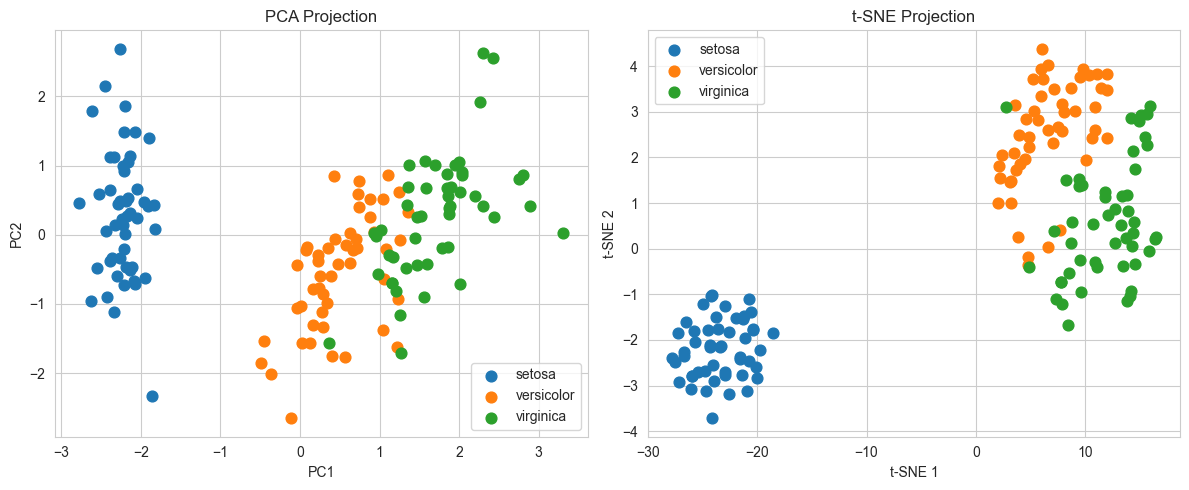

✅ t-SNE visualization complete — notice better cluster separation vs PCA!


In [ ]:
# t-SNE VISUALIZATION
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)  # n_iter → max_iter
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, label in enumerate(iris.target_names):
    plt.scatter(X_pca[y_iris == i, 0], X_pca[y_iris == i, 1], label=label, s=60)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.subplot(1, 2, 2)
for i, label in enumerate(iris.target_names):
    plt.scatter(X_tsne[y_iris == i, 0], X_tsne[y_iris == i, 1], label=label, s=60)
plt.title("t-SNE Projection")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()

plt.tight_layout()
plt.show()

print("t-SNE visualization complete — notice better cluster separation vs PCA!")

## 5. Association Rule Mining (Apriori)
Association Rule Mining finds interesting relationships between variables.
Key metrics:
- **Support**: How frequently an itemset appears
- **Confidence**: How often the rule is correct
- **Lift**: Strength of rule vs random chance (lift > 1 = positive correlation)

In [ ]:
# ASSOCIATION RULE MINING — CONCEPT DEMO
# Small demo dataset
transactions_demo = [
    ['milk', 'bread', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['milk', 'bread', 'butter', 'eggs'],
    ['bread', 'eggs'],
    ['milk', 'eggs'],
    ['bread', 'butter', 'eggs'],
]

te = TransactionEncoder()
te_array = te.fit_transform(transactions_demo)
df_demo = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets_demo = apriori(df_demo, min_support=0.3, use_colnames=True)
rules_demo = association_rules(frequent_itemsets_demo, metric="lift", min_threshold=1.0)

print("📦 Frequent Itemsets:")
print(frequent_itemsets_demo.sort_values('support', ascending=False))
print("\nAssociation Rules:")
print(rules_demo[['antecedents', 'consequents', 'support', 'confidence', 'lift']].round(3))

📦 Frequent Itemsets:
   support                    itemsets
0    0.750          frozenset({bread})
1    0.625         frozenset({butter})
3    0.625           frozenset({milk})
2    0.500           frozenset({eggs})
4    0.500  frozenset({bread, butter})
5    0.375    frozenset({bread, eggs})
6    0.375    frozenset({bread, milk})
7    0.375   frozenset({milk, butter})

📏 Association Rules:
           antecedents          consequents  support  confidence   lift
0   frozenset({bread})  frozenset({butter})    0.500       0.667  1.067
1  frozenset({butter})   frozenset({bread})    0.500       0.800  1.067
2   frozenset({bread})    frozenset({eggs})    0.375       0.500  1.000
3    frozenset({eggs})   frozenset({bread})    0.375       0.750  1.000


## 6. Market Basket Analysis Project
**Objective:** Apply Association Rule Mining on a real grocery market basket dataset
to discover purchasing patterns and product relationships.

**Dataset:** Groceries Dataset (~9,800 transactions)

In [11]:
# MARKET BASKET ANALYSIS — LOAD & EXPLORE

df = pd.read_csv('Groceries_dataset.csv', header=None)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Flatten all items to count frequency
all_items = df.values.flatten()
all_items = [item for item in all_items if str(item) != 'nan']

item_counts = pd.Series(all_items).value_counts()

print(f"\nTotal transactions: {len(df)}")
print(f"Unique items: {len(item_counts)}")
print(f"\nTop 10 most purchased items:")
print(item_counts.head(10))

Dataset Shape: (38766, 3)

First 5 rows:
               0           1                 2
0  Member_number        Date   itemDescription
1           1808  21-07-2015    tropical fruit
2           2552  05-01-2015        whole milk
3           2300  19-09-2015         pip fruit
4           1187  12-12-2015  other vegetables

Total transactions: 38766
Unique items: 4796

Top 10 most purchased items:
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64


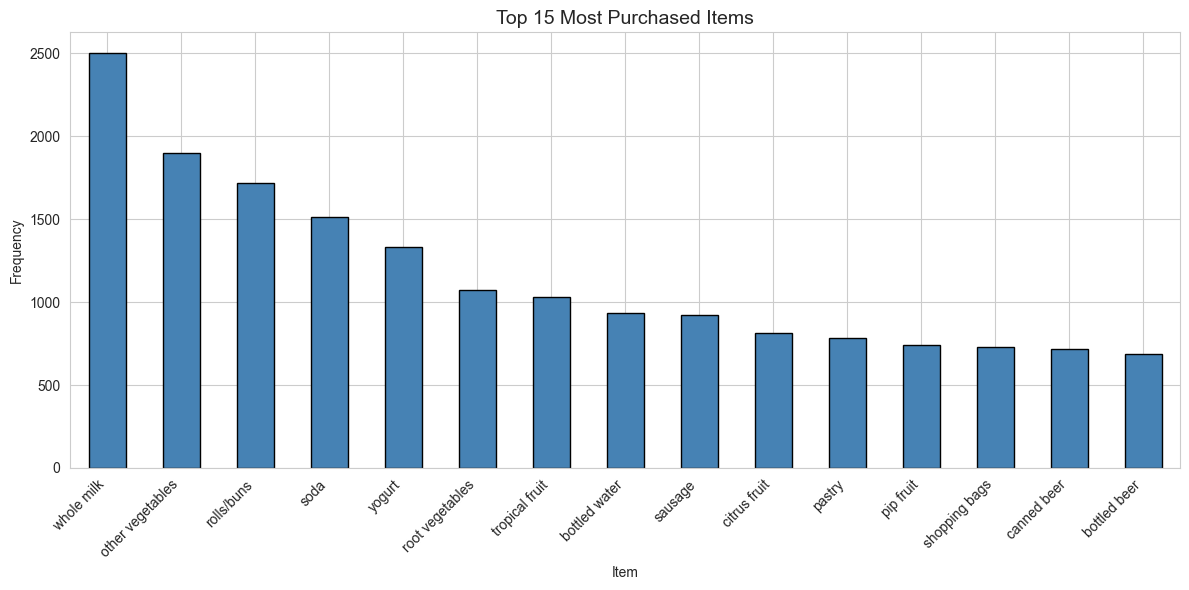

In [12]:
# VISUALIZE TOP ITEMS

plt.figure(figsize=(12, 6))
item_counts.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Top 15 Most Purchased Items", fontsize=14)
plt.xlabel("Item")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# PREPROCESSING & APRIORI
# Convert to list of transactions
transactions = []
for i in range(len(df)):
    transaction = [str(df.values[i, j]) for j in range(df.shape[1])
                   if str(df.values[i, j]) != 'nan']
    transactions.append(transaction)

# Encode
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded DataFrame Shape: {df_encoded.shape}")

# Apply Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"\n Frequent Itemsets Found: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Encoded DataFrame Shape: (38766, 4796)

 Frequent Itemsets Found: 11
     support                       itemsets  length
9   0.064541        frozenset({whole milk})       1
2   0.048960  frozenset({other vegetables})       1
4   0.044266        frozenset({rolls/buns})       1
7   0.039055              frozenset({soda})       1
10  0.034412            frozenset({yogurt})       1
5   0.027627   frozenset({root vegetables})       1
8   0.026621    frozenset({tropical fruit})       1
0   0.024067     frozenset({bottled water})       1
6   0.023835           frozenset({sausage})       1
1   0.020946      frozenset({citrus fruit})       1


Total Rules Generated: 0

🏆 Top 10 Rules by Lift:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


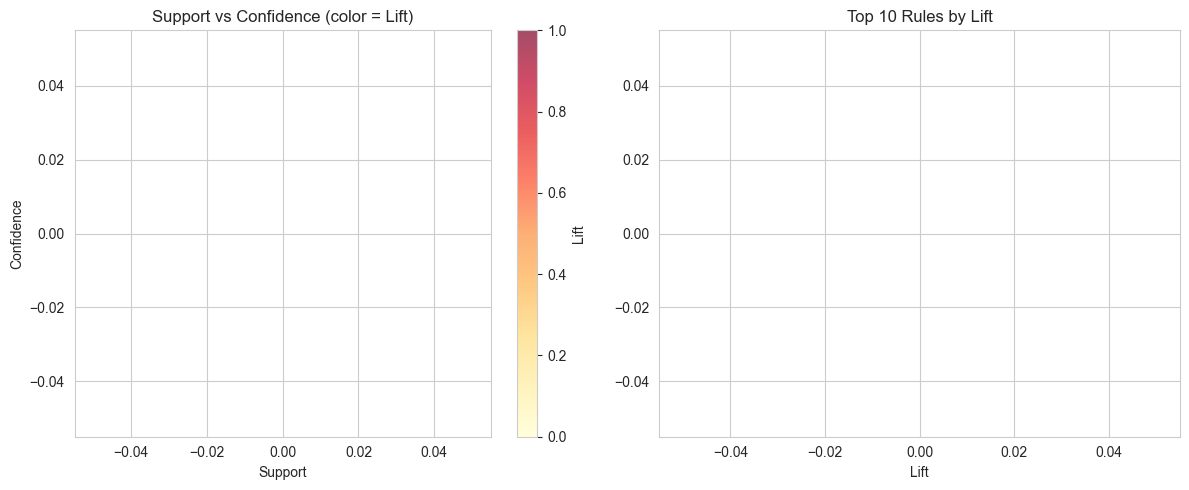

In [ ]:
# GENERATE ASSOCIATION RULES & INSIGHTS

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
rules = rules.sort_values('lift', ascending=False)

print(f"Total Rules Generated: {len(rules)}")
print("\n  Top 10 Rules by Lift:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).round(3))

# Visualize — Support vs Confidence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(rules['support'], rules['confidence'],
            c=rules['lift'], cmap='YlOrRd', alpha=0.7, s=50)
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence (color = Lift)')

# Top rules bar chart
plt.subplot(1, 2, 2)
top_rules = rules.head(10)
labels = [f"{list(r.antecedents)[0]} → {list(r.consequents)[0]}"
          for _, r in top_rules.iterrows()]
plt.barh(labels, top_rules['lift'], color='coral', edgecolor='black')
plt.xlabel('Lift')
plt.title('Top 10 Rules by Lift')
plt.tight_layout()
plt.show()

## 7. Conclusion

| Topic | Key Takeaway |
|---|---|
| K-Means (Scratch) | Iteratively assigns points to nearest centroid |
| Hierarchical Clustering | Builds tree of clusters, no need to specify K upfront |
| PCA | Reduces dimensions while preserving maximum variance |
| t-SNE | Better for visualization, captures non-linear structure |
| Apriori | Finds frequent itemsets and association rules efficiently |
| Market Basket Analysis | Revealed strong product associations (e.g., whole milk → other veg) |

**Key insight from Market Basket Analysis:**
Products with high lift indicate strong buying associations — useful for product placement and recommendations in retail.